# Data Preprocessing

## Objective

Prepare the dataset for machine learning by cleaning, transforming, and encoding the data based on the insights obtained during Exploratory Data Analysis (EDA).

The objective is to convert the raw dataset into a clean, consistent, and model-ready dataset while preserving meaningful information.

---

## Questions

- How should missing values be handled?
- Which missing values represent the absence of a feature?
- Which categorical features are ordinal and which are nominal?
- Which encoding technique should be used for each categorical feature?
- Which numerical features require scaling?
- Are there skewed features that require transformation?
- Are there highly correlated features that need special consideration?
- Can new informative features be engineered from the existing features?
- Is the final dataset suitable for machine learning models?

---

## Expected Outcome

By the end of preprocessing, the dataset should:

- Contain no inappropriate missing values.
- Have categorical features encoded appropriately.
- Have numerical features transformed or scaled where necessary.
- Include any useful engineered features.
- Be clean, consistent, and ready for model training.

---

In [1]:
import pandas as pd
df=pd.read_csv('../data/train.csv')
total_rows=len(df)

## *Part A: Missing Values Handling*
---

## Step 1: Create a Missing Value Summary Table

In [2]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100,
    "Data_Type": df.dtypes
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Percentage", ascending=False)
)

missing_summary



,Missing_Count,Missing_Percentage,Data_Type
PoolQC,1453,99.520548,str
MiscFeature,1406,96.301370,str
Alley,1369,93.767123,str
Fence,1179,80.753425,str
MasVnrType,872,59.726027,str
FireplaceQu,690,47.260274,str
LotFrontage,259,17.739726,float64
GarageType,81,5.547945,str
GarageYrBlt,81,5.547945,float64
GarageFinish,81,5.547945,str


## Step 2: Identify Features Where Missing Values Represent Feature Absence

### Objective

Determine whether missing values indicate that the corresponding feature is absent rather than the information being unavailable.

---

### Observation

Based on the data dictionary and EDA, several missing values occur because the corresponding feature does not exist for certain houses.

Examples include:

- Houses without a garage
- Houses without a pool
- Houses without a fireplace
- Houses without alley access
- Houses without miscellaneous features

These missing values are informative and therefore should not be treated as unknown values.

---

## Confirmed Feature-Absence Groups

### Garage Features

- GarageType
- GarageFinish
- GarageQual
- GarageCond
- GarageYrBlt

**Interpretation:** Missing values indicate that the house does not have a garage.

---

### Other Features

- PoolQC → No Pool
- FireplaceQu → No Fireplace
- Alley → No Alley Access
- Fence → No Fence
- MiscFeature → No Miscellaneous Feature


-Keeping these values as `NaN` would incorrectly imply missing information. Replacing them with `"None"` explicitly preserves the semantic meaning that the feature is absent.


---

## Features Requiring Further Investigation

Not all missing values can be directly interpreted as feature absence.

The following features require further analysis before selecting an imputation strategy.


### Basement Features

- BsmtQual
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinType2

### Remaining Features

- LotFrontage
- MasVnrType
- MasVnrArea
- Electrical
  
---

In [3]:
basement_features = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

df[basement_features].isnull().sum()

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
dtype: int64

In [4]:
df[df["BsmtExposure"].isnull() & df["BsmtQual"].notnull()][basement_features]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
948,Gd,TA,NaN,Unf,Unf


In [5]:
df[df["BsmtFinType2"].isnull() & df["BsmtQual"].notnull()][basement_features]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
332,Gd,TA,No,GLQ,NaN


## Step 3: Investigate Basement Features

### Objective

Investigate the basement-related features with missing values to determine whether the missing values represent feature absence or data inconsistencies.

---

### Observation

The missing counts for the basement-related features were compared.

| Feature | Missing Count |
|---------|---------------:|
| BsmtQual | 37 |
| BsmtCond | 37 |
| BsmtExposure | 38 |
| BsmtFinType1 | 37 |
| BsmtFinType2 | 38 |

If the missing values were solely due to the absence of a basement, all basement-related features would have identical missing counts.

The mismatch indicates that a small number of observations require further investigation.

---

### Investigation

#### Case 1: BsmtExposure

One observation contained:

- BsmtQual = Gd
- BsmtCond = TA
- BsmtFinType1 = Unf
- BsmtFinType2 = Unf
- BsmtExposure = NaN

Since all other basement attributes were present, the house clearly has a basement.

Therefore, the missing value in `BsmtExposure` is most likely a data entry error rather than the absence of a basement.

**Decision**

Replace the missing value with `"No"`.

---

#### Case 2: BsmtFinType2

One observation contained:

- BsmtQual = Gd
- BsmtCond = TA
- BsmtExposure = No
- BsmtFinType1 = GLQ
- BsmtFinType2 = NaN

The basement exists, but there is insufficient information to infer the correct basement finish type.

Therefore, a statistical imputation method is appropriate.

**Decision**

Replace the missing value with the mode of `BsmtFinType2`.

---

In [6]:
df.loc[
    df["BsmtExposure"].isnull() & df["BsmtQual"].notnull(),
    "BsmtExposure"
] = "No"

df.loc[
    df["BsmtFinType2"].isnull() & df["BsmtQual"].notnull(),
    "BsmtFinType2"
] = df["BsmtFinType2"].mode()[0]

In [7]:
df[basement_features].isnull().sum()  #verification

BsmtQual        37
BsmtCond        37
BsmtExposure    37
BsmtFinType1    37
BsmtFinType2    37
dtype: int64

## Step 4: Investigate  MasVnrType & MasVnrArea

### Objective

Investigate the masonry veneer-related features to determine whether the missing values represent feature absence or genuine missing information.

### Observation

According to the dataset documentation:

- `MasVnrType` describes the type of masonry veneer applied to the house.
- One valid category is **"None"**, indicating that the house has **no masonry veneer**.

Since `MasVnrType` and `MasVnrArea` describe the same property, they should be investigated together before selecting an imputation strategy.

### Next Step

Verify how the dataset represents houses with **no masonry veneer** and determine whether the missing values correspond to feature absence or genuine missing data.

---

In [8]:
df["MasVnrType"].value_counts(dropna=False)

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [9]:
df.loc[
    df["MasVnrArea"].isnull(),
    ["MasVnrType", "MasVnrArea"]
]

,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


### Investigation: MasVnrType & MasVnrArea

`MasVnrType` and `MasVnrArea` were investigated together because both describe the masonry veneer of a house.

According to the data dictionary, `"None"` is a valid category for `MasVnrType`, representing houses without masonry veneer.

Inspection of the dataset showed that the `"None"` category is stored as `NaN` rather than as a string.

Furthermore, all observations with missing `MasVnrArea` also had missing `MasVnrType`, indicating that these houses do not have masonry veneer.

Therefore, these missing values represent **feature absence** rather than genuine missing information.

### Preprocessing Decision

During the missing value handling stage:

- `MasVnrType` missing values will be replaced with `"None"`.
- `MasVnrArea` missing values will be replaced with `0`.
---

In [10]:
# Houses without masonry veneer have zero masonry veneer area
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

## Step 5: Investigation: LotFrontage

### Objective

Investigate the missing values in `LotFrontage` and determine an appropriate imputation strategy.

### Questions

- Is the distribution skewed?
- Are outliers present?
- Is the median a better estimate than the mean?
- Would neighborhood-wise imputation better preserve the characteristics of different locations?

----

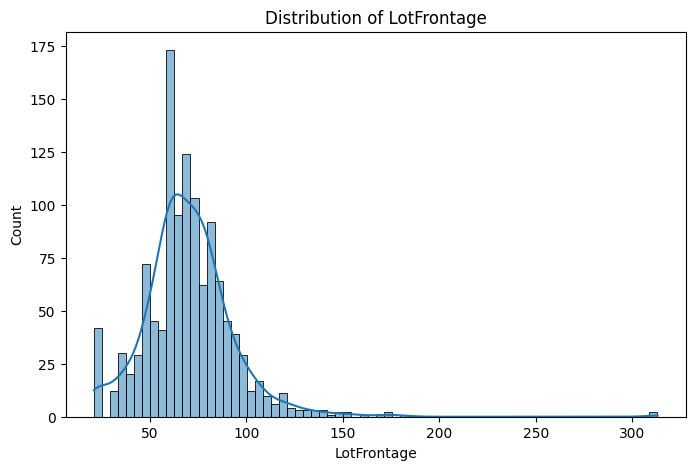

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["LotFrontage"], kde=True)

plt.title("Distribution of LotFrontage")
plt.xlabel("LotFrontage")
plt.ylabel("Count")
plt.show()

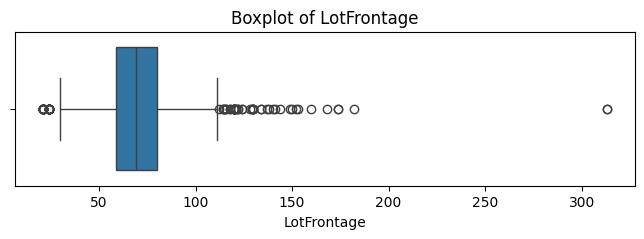

In [12]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["LotFrontage"])

plt.title("Boxplot of LotFrontage")
plt.show()

### Investigation: LotFrontage

`LotFrontage` exhibits a **right-skewed distribution** with several high-value outliers.

Since the mean is sensitive to extreme values, it is shifted toward the higher frontage values and does not accurately represent a typical house.

The **median** is more robust to outliers and provides a better estimate of the central tendency.

### Preprocessing Decision

Missing values in `LotFrontage` will be imputed using the **median** rather than the mean.

---

### Improved Imputation Strategy

Although the median is more robust than the mean for a right-skewed distribution, using a **single global median** may ignore differences between neighborhoods.

Since `LotFrontage` is strongly influenced by the location and size of the property, houses in different neighborhoods tend to have different frontage distributions.

Therefore, imputing missing values using the **median LotFrontage within each Neighborhood** better preserves the characteristics of individual neighborhoods and is expected to produce more realistic estimates.

### Preprocessing Decision

Missing values in `LotFrontage` will be imputed using the **median LotFrontage of the corresponding Neighborhood**.

---

In [13]:
df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [14]:
df["LotFrontage"] = (
    df.groupby("Neighborhood")["LotFrontage"]
      .transform(lambda x: x.fillna(x.median()))
)

## Step 6: Investigation: Electrical

### Objective

Investigate the missing value in `Electrical` to determine whether it represents feature absence or genuine missing information and decide an appropriate imputation strategy.

In [15]:
df.loc[df["Electrical"].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [16]:
df["Electrical"].value_counts(dropna=False)

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

In [17]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

### Investigation Findings

The missing value in `Electrical` represents **genuine missing information** rather than feature absence, as every house is expected to have an electrical system and the dataset description does not define a `None` category.

Only **one observation** is missing this value. Therefore, removing the entire row would unnecessarily reduce the training data.

Since the feature is categorical and one category is expected to dominate the distribution, imputing the missing value with the **mode** is an appropriate and statistically reasonable strategy.

### Preprocessing Decision

Impute the missing value in `Electrical` using the **most frequent category (mode)**.


---

## Step 9: Handle Feature Absence

### Objective

Replace missing values that represent **feature absence** with an explicit category (`"None"`).

### Rationale

During the missing value investigation, these features were identified as cases where a missing value indicates that the corresponding feature is **not applicable** rather than missing due to incomplete data collection.

Keeping these values as `NaN` would incorrectly imply missing information. Replacing them with `"None"` explicitly preserves the semantic meaning that the feature is absent.

### Preprocessing Decision

Replace missing values with `"None"` for all categorical features where `NaN` represents feature absence.

In [18]:
feature_absence = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

In [19]:
df[feature_absence] = df[feature_absence].fillna("None")

In [20]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

GarageYrBlt is missing only when a house has no garage. Since a numerical feature cannot take the categorical value "None", we use 0 as a sentinel value indicating the absence of a garage. This value is interpreted together with the garage-related categorical features, which have already been encoded as "None".

---

## Missing Value Handling Summary

### Objective

Handle missing values by distinguishing **feature absence** from **genuine missing information**, investigating ambiguous cases, and applying appropriate imputation strategies.

### Summary

- Created a missing value summary table to identify affected features.
- Categorized missing values into:
  - **Feature Absence** (e.g., no garage, no basement, no pool).
  - **Genuine Missing Values** requiring investigation.
- Investigated ambiguous basement records and corrected inconsistent entries.
- Identified missing masonry veneer values as feature absence and imputed accordingly.
- Imputed `LotFrontage` using the **Neighborhood-wise median** to preserve local characteristics.
- Imputed the single missing `Electrical` value using the **mode**.
- Replaced feature-absence categorical values with `"None"`.
- Filled `GarageYrBlt` with `0` as a sentinel value indicating the absence of a garage.

### Final Imputation Decisions

| Feature | Strategy |
|---------|----------|
| PoolQC, Alley, Fence, FireplaceQu | `"None"` |
| Garage categorical features | `"None"` |
| Basement categorical features | `"None"` |
| BsmtExposure | `"No"` (ambiguous record) |
| BsmtFinType2 | Mode (ambiguous record) |
| MasVnrType | `"None"` |
| MasVnrArea | `0` |
| LotFrontage | Neighborhood-wise median |
| Electrical | Mode (`SBrkr`) |
| GarageYrBlt | `0` |

### Conclusion

Missing values were handled using **dataset documentation, EDA findings, statistical reasoning, and domain knowledge**. This ensured that feature absence and genuine missing information were treated appropriately while preserving the integrity of the dataset.

In [21]:
verification = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

verification[verification["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage


-------------------------------

## *Part B: Feature Encoding*
---

## Step 1: Feature Classification

### Objective

Classify the dataset features based on their characteristics before applying encoding techniques.

### Why Perform This Step?

Machine learning algorithms require numerical input. However, categorical features are not all the same.

- **Ordinal features** have a natural order and should be encoded while preserving that order.
- **Nominal features** have no inherent order and require one-hot encoding.

Proper feature classification ensures that each feature is encoded using the appropriate technique.

---

## Step 1.1: Separate Numerical and Categorical Features

### Objective

Separate the dataset features into **numerical** and **categorical** groups based on their data types.

### Why Perform This Step?

Different types of features require different preprocessing techniques.

- **Numerical features** can be used directly for model training or may require feature scaling.
- **Categorical features** must be encoded into numerical representations before they can be used by machine learning algorithms.

Separating these features establishes the foundation for the subsequent preprocessing steps, including encoding and feature scaling.

### Conclusion

The dataset features have been classified into numerical and categorical groups. The categorical features will be further classified into **ordinal** and **nominal** features before applying the appropriate encoding techniques.

In [22]:
#Separate Numerical and Categorical Features
numerical_features = df.select_dtypes(include='number').columns.tolist()
categorical_features = df.select_dtypes(include=["str"]).columns.tolist()

numerical_features

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [23]:
print(f"Numerical Features : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features : 38
Categorical Features : 43


## Step 1.2: Classifying Categorical Features

### Objective

Classify the categorical features into **ordinal** and **nominal** groups before applying encoding techniques.

### Why Perform This Step?

Although all categorical features have the `object` data type, they do not all represent the same type of information.

- **Ordinal features** have a natural order or ranking (e.g., Poor < Fair < Typical < Good < Excellent). These features should be encoded while preserving their order.
- **Nominal features** have no inherent ordering (e.g., Neighborhood, MSZoning, GarageType). These features require encoding methods that do not introduce artificial ordering.

Since pandas only identifies these features as `object`, the classification is performed manually using the Ames Housing dataset documentation.

After identifying the ordinal features, the remaining categorical features are classified as nominal.

### Conclusion

The categorical features have been successfully classified into:

- **Ordinal features**, which will be encoded using ordinal mappings that preserve their natural ordering.
- **Nominal features**, which will be encoded using one-hot encoding in the subsequent preprocessing step.

In [24]:
# Ordinal features identified from the dataset documentation
ordinal_features = [
    "LotShape",
    "LandContour",
    "Utilities",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    "PoolQC",
    "Fence"
]

In [25]:
# Remaining categorical features are nominal
nominal_features = [
    feature for feature in categorical_features
    if feature not in ordinal_features
]

In [26]:
print(f"Ordinal Features : {len(ordinal_features)}")
print(f"Nominal Features : {len(nominal_features)}")

Ordinal Features : 21
Nominal Features : 22


In [27]:
print("Ordinal Features:")
print(ordinal_features)

print("\nNominal Features:")
print(nominal_features)

Ordinal Features:
['LotShape', 'LandContour', 'Utilities', 'LandSlope', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence']

Nominal Features:
['MSZoning', 'Street', 'Alley', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']


 ## Step 2: Ordinal Encoding

### Objective

Convert ordinal categorical features into numerical values while preserving their natural ordering.

### Why Perform This Step?

Ordinal features possess an inherent ranking (e.g., Poor < Fair < Typical < Good < Excellent). Preserving this order during encoding allows machine learning algorithms to learn the relative relationship between different categories.

Unlike nominal features, ordinal features should not be one-hot encoded because doing so would discard the ordinal information.

Therefore, each category is mapped to an integer according to its natural order using the Ames Housing dataset documentation.

### Conclusion

All ordinal features will be encoded using manually defined mappings that preserve their semantic ordering.

----

## Step 2.1: Encode Quality-Based Ordinal Features

### Objective

Encode quality-based ordinal features into numerical values while preserving their natural ordering.

### Why Perform This Step?

Several ordinal features in the dataset share the same quality scale:

> Poor < Fair < Typical/Average < Good < Excellent

Since these features have identical semantic ordering, a single mapping dictionary can be reused for all of them. This improves code reusability, reduces redundancy, and ensures consistent encoding across similar features.

For features where `"None"` represents the absence of the feature, `"None"` is encoded as `0` before applying the quality mapping.

### Features Included

- ExterQual
- ExterCond
- BsmtQual
- BsmtCond
- HeatingQC
- KitchenQual
- FireplaceQu
- GarageQual
- GarageCond
- PoolQC

### Conclusion

All quality-based ordinal features have been encoded using a common mapping while preserving their natural ordering.

---

In [28]:
# Features sharing the same quality scale
quality_features = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

# Common quality mapping
quality_map = {
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

# Encode quality features
for feature in quality_features:
    df[feature] = (
        df[feature]
        .replace("None", 0)
        .replace(quality_map)
    )

## Step 2.2: Encode Basement Exposure

### Objective

Encode the `BsmtExposure` feature while preserving its natural ordering.

### Why Perform This Step?

`BsmtExposure` is an ordinal feature representing the level of walkout or garden exposure of the basement.

The categories follow a natural progression from no exposure to good exposure. Therefore, the feature is encoded using an ordinal mapping. Houses without a basement are represented as `0` to distinguish feature absence from valid exposure levels.

### Conclusion

The `BsmtExposure` feature has been encoded while preserving its semantic ordering.

---

In [29]:
# Basement Exposure Mapping
bsmt_exposure_map = {
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

df["BsmtExposure"] = (
    df["BsmtExposure"]
    .replace("None", 0)
    .replace(bsmt_exposure_map)
)

## Step 2.3: Encode Basement Finish Type

### Objective

Encode the basement finish type features while preserving their natural ordering.

### Why Perform This Step?

`BsmtFinType1` and `BsmtFinType2` describe the quality of the finished basement area. These categories have an inherent progression from unfinished basements to high-quality finished living space.

Houses without a basement are represented as `0`, while the remaining categories are encoded according to their quality ranking.

### Features Included

- BsmtFinType1
- BsmtFinType2

### Conclusion

Both basement finish type features have been encoded while preserving their ordinal relationship.

---

In [30]:
# Basement Finish Type Features
bsmt_fin_features = [
    "BsmtFinType1",
    "BsmtFinType2"
]

# Basement Finish Type Mapping
bsmt_fin_map = {
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

for feature in bsmt_fin_features:
    df[feature] = (
        df[feature]
        .replace("None", 0)
        .replace(bsmt_fin_map)
    )

## Step 2.4: Encode Remaining Ordinal Features

### Objective

Encode the remaining ordinal features while preserving their respective natural ordering.

### Why Perform This Step?

Unlike the quality-based features, these variables represent different concepts such as property shape, land contour, utilities, land slope, garage finish, and fence quality. Since each feature has its own unique category ordering, separate mapping dictionaries are defined based on the Ames Housing dataset documentation.

For features where `"None"` represents the absence of the feature, it is encoded as `0` before applying the ordinal mapping.

### Features Included

- LotShape
- LandContour
- Utilities
- LandSlope
- GarageFinish
- PavedDrive
- Functional
- Fence

### Conclusion

Each remaining ordinal feature has been encoded using a feature-specific mapping while preserving its semantic ordering.

In [31]:
#mappings

# Lot Shape
lotshape_map = {
    "Reg": 4,
    "IR1": 3,
    "IR2": 2,
    "IR3": 1
}

# Land Contour
landcontour_map = {
    "Low": 1,
    "HLS": 2,
    "Bnk": 3,
    "Lvl": 4
}

# Utilities
utilities_map = {
    "ELO": 1,
    "NoSeWa": 2,
    "NoSewr": 3,
    "AllPub": 4
}

# Land Slope
landslope_map = {
    "Sev": 1,
    "Mod": 2,
    "Gtl": 3
}

# Garage Finish
garagefinish_map = {
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

# Paved Drive
paveddrive_map = {
    "N": 1,
    "P": 2,
    "Y": 3
}

# Functional
functional_map = {
    "Sal": 1,
    "Sev": 2,
    "Maj2": 3,
    "Maj1": 4,
    "Mod": 5,
    "Min2": 6,
    "Min1": 7,
    "Typ": 8
}

# Fence
fence_map = {
    "MnWw": 1,
    "GdWo": 2,
    "MnPrv": 3,
    "GdPrv": 4
}

In [32]:
# Apply mappings

df["LotShape"] = df["LotShape"].replace(lotshape_map)

df["LandContour"] = df["LandContour"].replace(landcontour_map)

df["Utilities"] = df["Utilities"].replace(utilities_map)

df["LandSlope"] = df["LandSlope"].replace(landslope_map)

df["GarageFinish"] = (
    df["GarageFinish"]
    .replace("None", 0)
    .replace(garagefinish_map)
)

df["PavedDrive"] = df["PavedDrive"].replace(paveddrive_map)

df["Functional"] = df["Functional"].replace(functional_map)

df["Fence"] = (
    df["Fence"]
    .replace("None", 0)
    .replace(fence_map)
)

## Step 3: Nominal Feature Encoding

### Objective

Transform all nominal categorical features into numerical representations using One-Hot Encoding.

### Why Perform This Step?

Nominal features do not have any natural ordering. Assigning numerical values to these categories would incorrectly introduce relationships between them.

One-Hot Encoding creates a separate binary column for each category, allowing the model to identify the presence or absence of a category without assuming any order.

### Why Use `OneHotEncoder`?

`OneHotEncoder` is used because it:

- Learns all categories from the training data.
- Creates the same set of output columns whenever new data is transformed.
- Can safely handle unseen categories using `handle_unknown="ignore"` without causing errors.

### Why Not `pd.get_dummies()`?

Although `pd.get_dummies()` also performs One-Hot Encoding, it is not used because:

- Applying it separately on different datasets can produce different columns if the categories differ.
- It does not automatically handle unseen categories.
- Additional manual code is required to make the columns of different datasets identical.

### Conclusion

All nominal categorical features are encoded using Scikit-Learn's `OneHotEncoder` to ensure consistent feature representation across datasets.

In [33]:
# import
from sklearn.preprocessing import OneHotEncoder

In [34]:
#create encoder
ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

### `handle_unknown="ignore"`

If a new category appears in unseen data that was not present during training, `OneHotEncoder` does not create a new column or raise an error.

Instead, it assigns **0** to all encoded columns for that feature, indicating that none of the known categories match.

This prevents feature mismatches and transformation errors because the model was never trained on the unseen category.

### `sparse_output=False`

By default, `OneHotEncoder` returns a sparse matrix to save memory because One-Hot Encoded data contains mostly zeros.

Since the Ames Housing dataset is relatively small, memory is not a concern. Therefore, `sparse_output=False` is used to return a regular NumPy array, making the encoded data easier to inspect, manipulate, and convert into a Pandas DataFrame.

##  Apply One-Hot Encoding

### Objective

Replace all nominal categorical features with their One-Hot Encoded representations.

### Steps Performed

1. Apply `OneHotEncoder` to all nominal features using `fit_transform()`.
2. Convert the encoded NumPy array into a Pandas DataFrame.
3. Assign meaningful column names using `get_feature_names_out()`.
4. Preserve the original row index to maintain correct row alignment.
5. Remove the original nominal categorical features from the dataset.
6. Concatenate the encoded features with the remaining dataset.

### Why Preserve the Original Index?

`OneHotEncoder` returns a NumPy array, which does not retain the original DataFrame index.

While converting the encoded array into a DataFrame, the original index is preserved using `index=df.index`. This ensures that every encoded row corresponds to the correct original observation when concatenating the transformed features back into the dataset.

### Result

The original nominal categorical features are replaced with binary encoded features, producing a fully numerical dataset suitable for machine learning algorithms.

In [35]:
# Apply One-Hot Encoding
encoded_array = ohe.fit_transform(df[nominal_features])

# Convert encoded array into a DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(nominal_features),
    index=df.index
)

# Remove original nominal features
df = df.drop(columns=nominal_features)

# Add encoded features to the dataset
df = pd.concat([df, encoded_df], axis=1)

# Display first few rows
df.head()

,Id,MSSubClass,LotFrontage,LotArea,LotShape,LandContour,Utilities,LandSlope,OverallQual,OverallCond,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,4,4,4,3,7,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,20,80.0,9600,4,4,4,3,6,8,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,60,68.0,11250,3,4,4,3,7,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4,70,60.0,9550,3,4,4,3,7,5,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,60,84.0,14260,3,4,4,3,8,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


----

## *Part B: Categorical Feature Encoding  Summary* 

### Objective

Prepare categorical features for machine learning by converting them into appropriate numerical representations.

### Steps Performed

1. **Classified features** into:
   - Numerical Features
   - Categorical Features

2. **Further classified categorical features** into:
   - Ordinal Features
   - Nominal Features

3. **Applied Ordinal Encoding**
   - Used predefined mappings based on the natural ordering of categories.
   - Filled missing values with `0` before encoding.
   - Reused common mappings for features sharing the same ordering.

4. **Applied One-Hot Encoding**
   - Encoded all nominal features using `OneHotEncoder`.
   - Converted the encoded output into a Pandas DataFrame.
   - Assigned meaningful feature names.
   - Preserved the original row index.
   - Removed the original nominal features and concatenated the encoded features back into the dataset.

### Result

All categorical features were successfully converted into numerical representations, resulting in a dataset ready for numerical feature preprocessing.

---

## 🛠️ *Part C — Feature Engineering*

### Objective

The goal of feature engineering is to create new, more informative features from the existing data that better represent the underlying relationships affecting the target variable.

Instead of relying only on the raw features provided in the dataset, we use domain knowledge and logical relationships to derive features that make learning easier for the machine learning model.

---

### Why Do We Perform Feature Engineering?

Real-world datasets often contain features that describe only parts of a larger concept. For example, multiple features may individually describe different aspects of the same property.

By combining or transforming these related features, we can create a higher-level feature that better captures the information needed for prediction.

> The objective is **not** to increase the number of features, but to increase the **quality and usefulness** of the information available to the model.

---

### Goals of Feature Engineering

- Create more meaningful features
- Capture hidden relationships between existing features
- Better represent real-world concepts
- Improve the predictive power of the dataset
- Help the model learn important patterns more easily
- Improve model generalization on unseen data

---

### Common Feature Engineering Techniques

Some commonly used feature engineering techniques include:

1. Combining multiple related features
2. Creating ratio or percentage features
3. Calculating differences between related values
4. Extracting useful information from dates and timestamps
5. Applying mathematical transformations (e.g., logarithmic transformation)
6. Creating interaction features between variables
7. Grouping categories using domain knowledge

> The choice of technique depends on the dataset and the problem being solved.

---

### Why Is Feature Engineering Performed Before Feature Scaling?

The preprocessing pipeline followed in this project is:

```
Missing Value Handling
        ↓
Categorical Encoding
        ↓
Feature Engineering
        ↓
Feature Scaling
        ↓
Model Training
```

Feature engineering is performed **before** feature scaling because engineered features should be created using the **original feature values**, where the numerical relationships still have their real-world meaning.

**Examples:**

- `House Age = Year Sold − Year Built`
- `Total Living Area = Basement Area + First Floor Area + Second Floor Area`

These operations represent meaningful real-world quantities. If the features were scaled first, these calculations would no longer correspond to actual years or square feet — making the engineered features difficult to interpret.

**Therefore, feature engineering should always be completed before scaling.**

---

### Feature Engineering vs. Feature Scaling

| Aspect | Feature Engineering | Feature Scaling |
|---|---|---|
| **Purpose** | Creates new informative features | Changes the numerical scale of existing features |
| **Approach** | Uses domain knowledge and logical relationships | Uses mathematical transformations |
| **Effect** | Improves feature representation | Improves optimization during model training |
| **Meaning** | Preserves real-world meaning | Standardizes feature magnitudes |
| **Order** | Performed before scaling | Performed after all feature engineering is complete |

---

### Key Takeaway

> **Feature engineering focuses on improving the quality of information available to the model, while feature scaling prepares the final feature set for efficient learning. Therefore, feature engineering should always be completed before feature scaling.**

---

## Feature Engineering Decision Framework
```
1. Identify the real-world concept.

        ↓

2. Understand how it is currently represented.

       ↓

3. Evaluate whether the representation is sufficient.

      ↓

4. Think of possible improvements.

      ↓

5. Decide whether feature engineering is justified.

      ↓

6. Implement only if it adds value.

```

---

## Step 1: Identify Feature Engineering Opportunities

Before creating new features, it is important to understand how the real-world concepts are represented in the dataset.

Instead of analyzing individual features independently, we first identify the major concepts that describe a house (e.g., age, size, quality, garage, and location) and map the corresponding dataset features to each concept.

This process helps identify potential feature engineering opportunities where existing features can be transformed, combined, or represented more effectively.

At this stage, no new features are created. The objective is to understand the current representation of each concept and build a feature engineering plan for the subsequent steps.

In [43]:
# Group dataset features by the real-world concepts they represent

feature_groups = {

    # -------------------------
    # Age & Timeline
    # -------------------------
    "Age": [
        "YearBuilt",
        "YearRemodAdd",
        "GarageYrBlt",
        "YrSold"
    ],

    # -------------------------
    # House Size & Area
    # -------------------------
    "Size": [
        "LotArea",
        "GrLivArea",
        "TotalBsmtSF",
        "1stFlrSF",
        "2ndFlrSF",
        "GarageArea",
        "MasVnrArea",
        "WoodDeckSF",
        "OpenPorchSF",
        "EnclosedPorch",
        "3SsnPorch",
        "ScreenPorch",
        "PoolArea",
        "LowQualFinSF"
    ],

    # -------------------------
    # Quality & Condition
    # -------------------------
    "Quality": [
        "OverallQual",
        "OverallCond",
        "ExterQual",
        "ExterCond",
        "KitchenQual",
        "HeatingQC",
        "BsmtQual",
        "BsmtCond",
        "GarageQual",
        "GarageCond",
        "FireplaceQu",
        "PoolQC"
    ],

    # -------------------------
    # Garage
    # -------------------------
    "Garage": [
        "GarageType",
        "GarageFinish",
        "GarageCars",
        "GarageArea",
        "GarageQual",
        "GarageCond",
        "GarageYrBlt"
    ],

    # -------------------------
    # Location
    # -------------------------
    "Location": [
        "Neighborhood",
        "MSZoning",
        "Condition1",
        "Condition2",
        "Street",
        "Alley",
        "LotConfig",
        "LandContour",
        "LandSlope"
    ],

    # -------------------------
    # Rooms & Layout
    # -------------------------
    "Rooms": [
        "BedroomAbvGr",
        "KitchenAbvGr",
        "TotRmsAbvGrd",
        "FullBath",
        "HalfBath",
        "BsmtFullBath",
        "BsmtHalfBath"
    ],

    # -------------------------
    # Basement
    # -------------------------
    "Basement": [
        "BsmtExposure",
        "BsmtFinType1",
        "BsmtFinType2",
        "BsmtFinSF1",
        "BsmtFinSF2",
        "BsmtUnfSF",
        "TotalBsmtSF",
        "BsmtQual",
        "BsmtCond"
    ],

    # -------------------------
    # Exterior
    # -------------------------
    "Exterior": [
        "Exterior1st",
        "Exterior2nd",
        "MasVnrType",
        "MasVnrArea",
        "RoofStyle",
        "RoofMatl",
        "Foundation"
    ],

    # -------------------------
    # Utilities & Services
    # -------------------------
    "Utilities": [
        "Utilities",
        "Heating",
        "HeatingQC",
        "CentralAir",
        "Electrical"
    ],

    # -------------------------
    # Outdoor Amenities
    # -------------------------
    "Outdoor": [
        "Fence",
        "PoolArea",
        "PoolQC",
        "MiscFeature",
        "Fireplaces",
        "FireplaceQu",
        "WoodDeckSF",
        "OpenPorchSF",
        "EnclosedPorch",
        "3SsnPorch",
        "ScreenPorch"
    ]
}

### Observations

- The dataset features were grouped based on the real-world concepts they represent rather than treating each feature independently.
- Some features belong to multiple concepts. For example, `GarageArea` contributes to both the **Size** and **Garage** concepts, while `GarageYrBlt` relates to both **Age** and **Garage**.
- This grouping serves as a planning step for feature engineering and helps identify concepts that may benefit from transformation or aggregation in the following steps.

---

## Step 2.1 Evaluate the Age Concept

The Age concept is currently represented using event-based features such as `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, and `YrSold`.

Instead of directly describing the age of the house, these features record when specific events occurred. Since age is a more meaningful representation of this concept, a new feature (`HouseAge`) is created.

Based on the EDA findings, `YrSold` showed a weak relationship with the target variable and spanned only a small range (2006–2010). Furthermore, after creating `HouseAge`, `YrSold` becomes redundant because it can be derived from `YearBuilt` and `HouseAge`.

`YearBuilt` is retained because it provides additional information about the construction era, which may capture characteristics such as building standards, materials, and design trends that are not fully represented by `HouseAge`.

In [37]:
# Create a feature representing the age of the house at the time of sale
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# Drop YrSold as it becomes redundant
df.drop(columns="YrSold", inplace=True)

In [38]:
df[["YearBuilt", "HouseAge"]].head()

,YearBuilt,HouseAge
0,2003,5
1,1976,31
2,2001,7
3,1915,91
4,2000,8


In [39]:
df["HouseAge"].corr(df["SalePrice"])

np.float64(-0.523350417546816)

---

### Transformation vs Aggregation

Feature engineering commonly follows two patterns:

- **Transformation:** Change the representation of existing information into a more meaningful feature without introducing new information.
  - Example: `HouseAge = YrSold - YearBuilt`

- **Aggregation:** Combine multiple related features that describe different parts of the same concept into a single feature.
  - Example: `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF`

**Rule of thumb:**
- If you're changing *how* information is represented, it's **Transformation**.
- If you're combining *parts of the same concept*, it's **Aggregation**.

----



### Avoid Creating Redundant Features

Not every possible engineered feature should be created.

Before adding a new feature, evaluate whether it introduces new information or simply duplicates information already available in existing features.

A feature is generally not useful if it:

- Can be directly inferred from another feature.
- Does not provide additional information.
- Only repeats an existing representation in a different form.

---

### 2.2 Evaluate the Size Concept

The Size concept is represented across multiple area-related features. Instead of directly describing the overall indoor size of the house, the information is distributed across different sections such as the above-ground living area and the basement.

An aggregated feature, `TotalSF`, is created by combining `GrLivArea` and `TotalBsmtSF` to represent the total indoor house area.

Features such as `GarageArea` and `LotArea` are not included because they represent different real-world concepts (garage space and land area, respectively). Aggregating features is meaningful only when they describe the same underlying concept.

The original area-related features are retained because they provide detailed information about the distribution of space, which may contain additional predictive value beyond the aggregated feature.

In [40]:
df["TotalIndoorArea"] = df["GrLivArea"] + df["TotalBsmtSF"]

In [42]:
df[["GrLivArea", "TotalBsmtSF", "TotalIndoorArea"]].head()

,GrLivArea,TotalBsmtSF,TotalIndoorArea
0,1710,856,2566
1,1262,1262,2524
2,1786,920,2706
3,1717,756,2473
4,2198,1145,3343


### Observations

- Created `TotalIndoorArea` to represent the overall indoor size of the house.
- Combined `GrLivArea` and `TotalBsmtSF` because they describe complementary parts of the indoor living space.
- Retained the original area-related features, as they preserve detailed information about the distribution of space that may still be useful for prediction.

---

### 2.3 Evaluate the Quality Concept

The Quality concept is already represented at multiple levels in the dataset.

`OverallQual` provides a high-level assessment of the overall material and finish quality of the house, while features such as `KitchenQual`, `GarageQual`, `BsmtQual`, and `HeatingQC` capture the quality of individual components.

Since both summary-level and detailed quality information are already available, additional aggregation is not justified at this stage. Therefore, no new feature is created for the Quality concept.

---

### 2.4 Evaluate the Garage Concept

The Garage concept is already represented through multiple complementary features, including garage size, capacity, quality, condition, finish, and type.

A potential engineered feature, `IsGaragePresent`, was evaluated but not created because the absence of a garage is already represented through existing garage-related features after preprocessing. Therefore, it would not introduce any new information.

Although `GarageCars` and `GarageArea` are highly correlated, they describe different aspects of the garage (capacity and physical size) and may each provide unique predictive information.

Therefore, no additional feature engineering is performed for the Garage concept at this stage.

---

### 2.5 Evaluate the Location Concept

The Location concept is represented through multiple complementary features, including neighborhood, zoning, road access, lot configuration, and nearby conditions.

These features describe different characteristics of a property's location rather than different parts of the same concept. Therefore, aggregating them would not produce a more meaningful representation.

No direct transformation or aggregation is justified, as the dataset already captures the Location concept from multiple perspectives.

Therefore, no additional feature engineering is performed for the Location concept.

---

### Feature Engineering and Multicollinearity

Feature engineering aims to create features that better represent the underlying problem. While engineered features may introduce multicollinearity, this is not inherently a feature engineering issue.

Whether multicollinearity needs to be addressed depends on the machine learning model being used. For example, it is an important consideration for linear models but is generally not a concern for tree-based models.

Therefore, feature engineering focuses on improving data representation, while multicollinearity is evaluated and handled during the modeling stage.

---

### 2.6 Evaluate the Rooms Concept

The Rooms concept is represented through individual features describing bedrooms, kitchens, bathrooms, and the total number of above-ground rooms.

The existing feature `TotRmsAbvGrd` already provides a summary of above-ground rooms. Therefore, creating another aggregated room-count feature would be redundant.

Bathroom information, however, is distributed across multiple features (`FullBath`, `HalfBath`, `BsmtFullBath`, and `BsmtHalfBath`). A candidate feature, `TotalBathrooms`, was identified because it may provide a more meaningful high-level representation of bathroom availability.

Before implementing this feature, it should be validated using both domain knowledge and exploratory data analysis (e.g., relationship with `SalePrice`) to determine whether it provides additional predictive value.

Therefore, no new feature is implemented at this stage. The engineering decision is postponed until validation.

---

In [44]:
# Candidate feature (to be validated)

df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

# Check correlation with SalePrice
df["TotalBathrooms"].corr(df["SalePrice"])

np.float64(0.6317310679319873)

### Validating an Engineered Feature

An engineered feature should be evaluated using both domain knowledge and data evidence.

If an engineered feature:

- Represents the concept more meaningfully, and
- Shows a stronger relationship with the target,

then it is justified as an additional feature.

However, this alone does not justify removing the original features. Original features should only be removed if they no longer provide unique or useful information beyond the engineered feature.

---

In [50]:
# Candidate Feature: Percentage of basement that is finished
df["FinishedBasementRatio"] = (
    (df["TotalBsmtSF"] - df["BsmtUnfSF"]) / df["TotalBsmtSF"]
)

# Houses with no basement (TotalBsmtSF = 0)
df["FinishedBasementRatio"] = df["FinishedBasementRatio"].fillna(0)

In [54]:
basement_features = [
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "FinishedBasementRatio",
    "SalePrice",
]

df[basement_features].corr()["SalePrice"].sort_values(ascending=False)

# Remove the rejected candidate feature
df.drop(columns="FinishedBasementRatio", inplace=True)

### Step 2.7: Evaluate the Basement Concept

The Basement concept is represented through multiple features describing its size, finished area, quality, condition, exposure, and finish type.

The dataset already provides both detailed and summary representations of the basement. For example, `BsmtFinSF1`, `BsmtFinSF2`, and `BsmtUnfSF` describe different portions of the basement, while `TotalBsmtSF` provides an overall summary of the basement size.

During evaluation, a candidate feature, **FinishedBasementRatio**, was identified to represent the proportion of the basement that is finished.

$$
FinishedBasementRatio
=
\frac{TotalBsmtSF - BsmtUnfSF}{TotalBsmtSF}
$$

From a domain perspective, this feature provides a meaningful representation of basement usability. However, validation using exploratory data analysis showed that its correlation with `SalePrice` (0.132) was weaker than the existing basement size features.

Therefore, there is insufficient evidence that the engineered feature provides additional predictive value.

**Decision:** No additional feature engineering is performed for the Basement concept.

---

### Step 2.8: Evaluate the Exterior Concept

The Exterior concept is represented through features describing the exterior materials, masonry, quality, and condition of the house.

The existing features capture different aspects of the exterior rather than fragmented information. No missing high-level representation or meaningful aggregation opportunity was identified.

**Decision:** The Exterior concept is already well represented. No additional feature engineering is performed.

---

### Step 2.9: Evaluate the Utilities Concept

The Utilities concept is represented through features describing the availability of essential services and house functionality.

The existing features already capture the relevant information directly, and no meaningful transformation or aggregation was identified.

**Decision:** The Utilities concept is already well represented. No additional feature engineering is performed.

---

### Step 2.10: Evaluate the Outdoor Concept

The Outdoor concept is represented through features describing decks, porches, pool area, fencing, and other outdoor amenities.

These features represent different outdoor facilities rather than fragmented information. No missing high-level representation or meaningful aggregation opportunity was identified.

**Decision:** The Outdoor concept is already well represented. No additional feature engineering is performed.

---

## Feature Engineering Summary

Using the Feature Engineering Decision Framework, each real-world concept was evaluated to determine whether new features should be created.

Based on domain knowledge and exploratory data analysis, the following engineered features were added to the dataset:

- `HouseAge`
- `TotalIndoorArea`
- `TotalBathrooms`

The following original feature was removed because its information was sufficiently captured by an engineered feature:

- `YrSold`

No additional feature engineering was required for the remaining concepts, as they were already well represented by the existing features.

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 226 entries, Id to TotalBathrooms
dtypes: float64(169), int64(36), object(21)
memory usage: 2.5+ MB


## *Part D: Feature Scaling*

## Step 1: Why is Feature Scaling Required?

Machine learning algorithms learn patterns by performing mathematical operations on feature values. For some algorithms, the magnitude of these values directly influences the learning process.

Consider two numerical features in this dataset:

- `LotArea` — measured in thousands of square feet.
- `OverallQual` — an ordinal feature with values ranging from 1 to 10.

Although both features may be equally informative for predicting house prices, their numerical scales differ substantially.

Algorithms that rely on **numerical optimization** or **distance calculations** operate directly on these values. Consequently, large differences in feature magnitudes can make optimization inefficient or allow larger-scale features to dominate distance computations.

Feature scaling transforms numerical features to a comparable scale, producing more balanced parameter updates for optimization-based algorithms and more meaningful distance calculations for distance-based algorithms. Importantly, scaling changes only the numerical representation of the features—it does not alter the underlying information contained within the data.
Therefore, feature scaling is not performed to improve the data itself, but to improve the learning process of algorithms that are sensitive to feature magnitudes.

---

## Step 2: Determine Whether Feature Scaling is Required

The requirement for feature scaling depends on the learning mechanism of the machine learning algorithm.

### Optimization-Based Models

Algorithms such as **Linear Regression**, **Ridge**, and **Lasso** learn model parameters by minimizing a cost function through numerical optimization.

When input features have substantially different numerical scales, the optimization process produces gradients of different magnitudes for different parameters. As a result, selecting an appropriate learning rate becomes more difficult, often leading to slower convergence or unstable optimization.

Scaling the features places them on a comparable numerical scale, allowing the optimization algorithm to update all model parameters more efficiently.

---

### Distance-Based Models

Algorithms such as **K-Nearest Neighbors (KNN)** and **Support Vector Machines (SVM)** compare observations using distance measures.

Without feature scaling, variables with larger numerical values contribute disproportionately to these distance calculations, reducing the influence of features measured on smaller scales.

Scaling ensures that distances reflect the contribution of all features rather than being dominated by their numerical magnitudes.

---

### Tree-Based Models

Tree-based algorithms, including **Decision Trees**, **Random Forests**, and **XGBoost**, learn by recursively partitioning the feature space.

Each split is determined by the ordering of feature values rather than their numerical magnitude. Multiplying or scaling a feature changes its numerical values but does not change their relative ordering.

Consequently, feature scaling has little to no effect on the behavior of tree-based models and is generally unnecessary.

---

## Step 3: Evaluate the Requirements of This Project

The primary objective of this project is to develop and evaluate **Linear Regression** models, followed by their regularized variants (**Ridge** and **Lasso**).

Since these models learn through numerical optimization, they are sensitive to differences in feature magnitudes. Therefore, feature scaling is required before model training.

Although tree-based models may be explored later for comparison, the preprocessing pipeline is primarily designed to support the linear models that form the focus of this project.

**Decision:** Feature scaling is required.

---

## Step 4: Select an Appropriate Scaling Technique

After determining that feature scaling is necessary, the next step is to select an appropriate scaling technique.

### MinMaxScaler

MinMaxScaler transforms each feature to a fixed range, typically **[0, 1]**.

This approach is useful when an algorithm explicitly requires bounded input values. However, the linear models developed in this project do not impose such a requirement.

Since constraining every feature to a fixed interval provides no additional benefit for our models, MinMaxScaler is not selected.

---

### RobustScaler

RobustScaler standardizes features using the **median** and **interquartile range (IQR)** instead of the mean and standard deviation.

Its primary advantage is reducing the influence of extreme outliers.

The Ames Housing dataset contains several genuine outliers that were intentionally retained because they represent valid observations rather than data errors.

However, at this stage there is no evidence that these observations significantly degrade the optimization process of the linear models being developed. Introducing a more robust scaling technique without such evidence would add unnecessary complexity to the preprocessing pipeline.

For this reason, RobustScaler is not selected as the initial scaling method. It remains a reasonable alternative if future model evaluation demonstrates that outliers adversely affect model performance.

---

### StandardScaler

StandardScaler standardizes each feature by subtracting its mean and dividing by its standard deviation.

Unlike MinMaxScaler, it does not constrain features to a fixed interval. Instead, it places numerical features on a comparable scale while preserving their relative variation.

For optimization-based linear models, this standardization improves the efficiency of parameter optimization without altering the underlying relationships between observations.

Based on the evaluation above:

- Feature scaling is required because the primary models are optimization-based.
- A fixed feature range is unnecessary.
- There is currently no evidence that a robust scaling strategy is required.

**Decision:** StandardScaler is selected as the feature scaling technique for this project.